In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from lite_org import LITE
from utils import load_data, preprocess_data
import os
import lite_org
from torch import nn
# from utils_ipynb import *
import gc

import torch.nn.functional as F
from sklearn.metrics import accuracy_score

In [16]:
def test(model):
    
    model.eval()
    test_loss, correct, total = 0, 0, 0

    for batch_idx, (inputs, targets) in enumerate(valloader):
        inputs, targets = inputs.cuda(), targets.cuda()

        outputs, _ = model(inputs.float())
        loss = criterion_CE(outputs, targets)
        
        test_loss += loss.item()
        
        _, predicted = torch.max(outputs.data, 1)
        total += targets.size(0)
        correct += predicted.eq(targets.data).cpu().sum().float().item()

    print('Test Loss: %.3f | Test Acc: %.3f%% (%d/%d)' % (test_loss / (batch_idx + 1), 100. * correct / total, correct, total))
    return test_loss / (batch_idx + 1), 100. * correct / total

criterion_CE = nn.CrossEntropyLoss()

In [17]:
seed = 9409
ds_names = ['ACSF1', ]
path = os.getcwd()

for _, dataset in enumerate(ds_names):
    rows = [dataset]
    xtrain, ytrain, xtest, ytest = load_data(dataset)

    trainloader = preprocess_data(xtrain, ytrain, shuffle=False)
    valloader = preprocess_data(xtest, ytest, shuffle=False,)

    length = xtrain.shape[-1]
    n_classes = len(np.unique(ytrain))

    model_base = LITE(None, length_TS=length, n_classes=n_classes)
    model_base.load_state_dict(torch.load(f'{path}/results/base_lite/base_seed_{seed}/{dataset}/best_model.pt'))
    model_base.cuda()
    test(model_base)

Test Loss: 0.330 | Test Acc: 89.000% (89/100)


/tmp/ipykernel_2510343/802152949.py:16: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model_base.load_state_dict(torch.load(f'{path}/results/base_lite/base_seed_{seed}/{data

In [20]:
sum([paramater.numel() for paramater in model_base.parameters() if paramater.requires_grad])

10144

In [21]:
red_df = pd.read_csv('red_df_part_1.csv')

In [23]:
red_df['norm_base_red_1'] = red_df['base_red_1'] / red_df['base_red_1']
red_df['norm_base_red_2'] = red_df['base_red_2'] / red_df['base_red_2']
red_df['norm_base_red_3'] = red_df['base_red_3'] / red_df['base_red_3']

red_df['norm_sparse_red_1'] = red_df['sparse_red_1'] / red_df['base_red_1']
red_df['norm_sparse_red_2'] = red_df['sparse_red_2'] / red_df['base_red_2']
red_df['norm_sparse_red_3'] = red_df['sparse_red_3'] / red_df['base_red_3']



In [24]:
red_df

,Dataset,base_red_1,base_red_2,base_red_3,sparse_red_1,sparse_red_2,sparse_red_3,norm_base_red_1,norm_base_red_2,norm_base_red_3,norm_sparse_red_1,norm_sparse_red_2,norm_sparse_red_3
0,ACSF1,746.300860,60.552127,35.254884,67.067123,15.647041,12.962895,1.0,1.0,1.0,0.089866,0.258406,0.367691
1,Adiac,491.390561,45.439697,38.898944,23.375287,7.009481,26.730252,1.0,1.0,1.0,0.047570,0.154259,0.687172
2,AllGestureWiimoteX,142.077178,22.714568,35.851115,8.590206,0.267727,1.597953,1.0,1.0,1.0,0.060462,0.011787,0.044572
3,AllGestureWiimoteY,144.069552,26.726552,38.424962,11.528166,0.236760,1.060837,1.0,1.0,1.0,0.080018,0.008859,0.027608
4,AllGestureWiimoteZ,288.001382,23.626249,35.186417,11.967642,0.701625,2.380738,1.0,1.0,1.0,0.041554,0.029697,0.067661
5,ArrowHead,474.867061,42.999485,53.473993,14.185177,4.211721,26.387816,1.0,1.0,1.0,0.029872,0.097948,0.493470
6,BeetleFly,306.993268,22.374215,75.646802,1.980838,0.914451,9.567835,1.0,1.0,1.0,0.006452,0.040871,0.126480
7,BirdChicken,357.974691,37.362901,88.822384,1.787660,0.104388,10.440254,1.0,1.0,1.0,0.004994,0.002794,0.117541
8,Beef,293.783851,27.719514,34.590214,80.546216,6.345649,22.235082,1.0,1.0,1.0,0.274168,0.228924,0.642814
9,BME,741.101674,55.721551,46.708943,5.419240,0.298644,20.141949,1.0,1.0,1.0,0.007312,0.005360,0.431223


p_value:  3.814697265625e-06


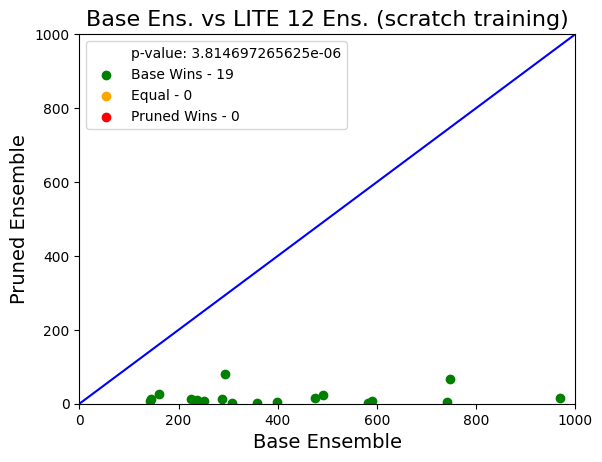

In [32]:
from utils import plot_1v1_perf
from scipy.stats import wilcoxon

# Perform the Wilcoxon signed-rank test
stat, p_value = wilcoxon(red_df['base_red_1'].tolist(), red_df['sparse_red_1'])
print('p_value: ', p_value)

plot_1v1_perf(red_df, 
              p_value, 
              x_y_lim=0.0, 
              acc_base=1000, 
              co_col='sparse_red_1', 
              base_col='base_red_1', 
              xlabel='Base Ensemble', 
              ylabel='Pruned Ensemble', 
              legend_base='Base', 
              legend_co='Pruned', 
              title='Base Ens. vs LITE 12 Ens. (scratch training)', 
              file_name='quantitative_redundancy')